In [48]:
## versions
# python==3.9.18
# x_transformers==1.31.14
# torch==2.5.1
# then for aTMi:
# pip installe -e .

In [5]:
# First figures for evaluation of aTMi on simulated data, then evaluation on real data

In [1]:
import warnings
warnings.filterwarnings("ignore")

import msprime
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from inference_lib import create_sawtooth_demogaphy_object
from inference_lib import CoalescenceTransformer
from inference_lib import load_model_checkpoint
from inference_lib import simulate_data
from inference_lib import run_inference
from inference_lib import plot_simulation
from inference_lib import plot_average_predictions
from inference_lib import plot_transition_matrix

from aTMi.config import population_times
population_time = population_times('arabidopsis_methyl')

def create_demography_object(sizes, times):
    demography = msprime.Demography()
    demography.add_population(name="pop0", initial_size=sizes[0])
    for i in range(1, len(sizes)):
        demography.add_population_parameters_change(
            time=times[i],
            initial_size=sizes[i],
            population="pop0"
        )
    return demography

In [2]:
few_params = {
    'seq_len': None,
    'enc_dim': 512,
    'enc_depth': 12, 
    'enc_heads': 10, 
    'in_dim': 42,
    'out_dim': 42
}

model = CoalescenceTransformer(**few_params)
device = torch.device("cuda")
model = model.to(device)
criterion = torch.nn.MSELoss()

In [ ]:
# fixed hyperparameters 
empirical_scaling_factor = np.exp(8.2)
window_size = 20_000

# and seeds
seeds = [1000, 2000, 3000, 4000, 5000]

TM tensor sum: tensor(336.5004)
Loss: tensor(0.0714, device='cuda:0')
TM sum: 336.50042724609375
TM tensor sum: tensor(340.7009)
Loss: tensor(0.0961, device='cuda:0')
TM sum: 340.7008972167969
TM tensor sum: tensor(318.9959)
Loss: tensor(0.0626, device='cuda:0')
TM sum: 318.99591064453125
TM tensor sum: tensor(334.1649)
Loss: tensor(0.1042, device='cuda:0')
TM sum: 334.16485595703125
TM tensor sum: tensor(335.4838)
Loss: tensor(0.1153, device='cuda:0')
TM sum: 335.48382568359375


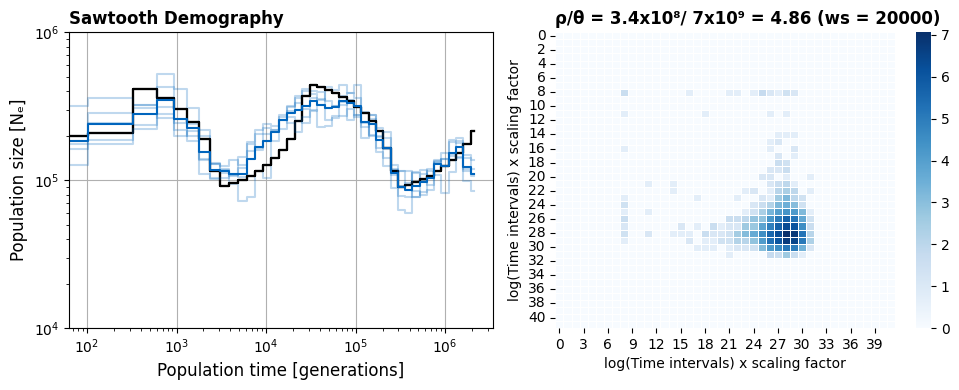

In [4]:
model_idx = 36
y_preds = []

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
ax_sim = axs[0]
ax_heat = axs[1]

for seed in seeds:
    # loading checkpointg
    model, model_idx = load_model_checkpoint(model, model_idx)

    # creating data
    sawtooth_demography_object = create_sawtooth_demogaphy_object(Ne=2*10**5, magnitue=8)
    tm_np, tm_tensor, pop_size_tensor = simulate_data(
        seed, sawtooth_demography_object, population_time, window_size, empirical_scaling_factor
    )

    # quick check to see transition matrix is roughly full
    print("TM tensor sum:", tm_tensor.sum())
    
    # run inference
    predictions, targets, loss = run_inference(model, tm_tensor, pop_size_tensor, criterion, device)

    # loss
    print("Loss:", loss)
    y_true = targets.detach().cpu().numpy()[0]
    y_pred = predictions.detach().cpu().numpy()[0]
    
    plot_simulation(ax_sim, population_time, y_true, y_pred)
    y_preds.append(y_pred)
    print(f"TM sum: {tm_tensor.sum()}")

plot_average_predictions(ax_sim, population_time, y_preds)
plot_transition_matrix(ax_heat, tm_np, window_size)

plt.tight_layout()
# plt.savefig("./figurs/Sawtooth-10-Simulations-rhotheta-5-and-tm.png", dpi=300)
plt.show()

y_preds = np.array(y_preds)

In [ ]:
#np.savez("./cache/sawtooth_y_preds.npz", y_preds)
#np.savez("./cache/sawtooth_tm.npz", tm_np)
#np.savez("./cache/sawtooth_y_true.npz", y_true)

In [ ]:
# Simulating under the inferred model: To show that summary stats, namely SFS broadly matches inference.

In [8]:
y_preds = np.load("./cache/sawtooth_y_preds.npz")['arr_0']
y_true = np.exp(np.load("./cache/sawtooth_y_true.npz")['arr_0'])
demography_object = create_sawtooth_demogaphy_object(Ne=2*10**5, magnitue=8)


avg_pred = np.array(y_preds).mean(0)
sizes = np.exp(avg_pred)
times = population_time
sim_tss = []
for seed in seeds:
    params = {
        'discrete_genome': True,
        'samples': 10, 
        'ploidy': 1,
        'demography': demography_object,
        'recombination_rate': 3.4e-8,
        'random_seed': seed,
        'sequence_length': 4_000_000
    }
    sim_ts = msprime.sim_ancestry(**params)
    sim_ts = msprime.mutate(sim_ts, rate=7e-9, random_seed=seed)
    sim_tss.append(sim_ts)

# simmulating under the inferred demography with replicates
inf_tss = []
for seed in seeds:
    demography_object = create_demography_object(sizes, times)
    params['demography'] = demography_object    
    params['random_seed'] = seed
    inf_ts = msprime.sim_ancestry(**params)
    inf_ts = msprime.mutate(inf_ts, rate=7e-9, random_seed=seed)
    inf_tss.append(inf_ts)

sim_sfs = []
inf_sfs = []
for i, seed in enumerate(seeds):
    sim_ts = sim_tss[i]
    inf_ts = inf_tss[i]
    sim_sfs.append(sim_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
    inf_sfs.append(inf_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
sim_sfs = np.array(sim_sfs)
inf_sfs = np.array(inf_sfs)

In [ ]:
#np.savez("./cache/sawtooth_sim_sfs.npz", sim_sfs, inf_sfs)

In [9]:
def plot_transition_matrix(ax, tm_np):
    """Plot a heatmap of the transition matrix on the given axis."""
    sns.heatmap(tm_np, cmap="Blues", annot=False, fmt=".2f", linewidths=.5, ax=ax)
    ax.set_xlabel("log(Time intervals) x scaling factor")
    ax.set_ylabel("log(Time intervals) x scaling factor")
    #ax.set_title(f"ρ/θ = 3.4x10⁸/ 7x10⁹ = 4.86)",
    #             fontsize=12, fontweight='bold', loc="left")

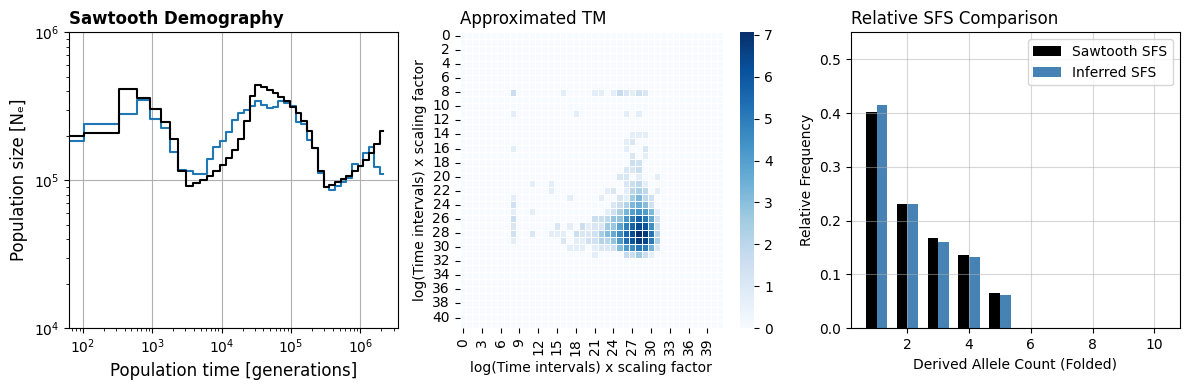

In [10]:
population_size = sizes
fig, axs = plt.subplots(1, 3, figsize=(12, 4))#, plt.gca()
ax = axs[0]
sns.lineplot(x=population_time, y=population_size, drawstyle="steps-mid", ax=ax)
sns.lineplot(x=population_time, y=y_true, drawstyle="steps-mid", color='black', ax=ax)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Population time [generations]", fontsize=12)
ax.set_title("Sawtooth Demography", fontsize=12, fontweight='bold', loc='left')

ax.grid()

ax = axs[1]
plot_transition_matrix(ax, tm_np)
ax.set_title("Approximated TM", loc='left')


ax = axs[2]
allele_counts = np.arange(1, sim_sfs.shape[1] + 1)
width = 0.35

# 1) Normalize each replicate to sum to 1, then take the mean across replicates
sim_rel = (sim_sfs / sim_sfs.sum(axis=1, keepdims=True)).mean(axis=0)
inf_rel = (inf_sfs / inf_sfs.sum(axis=1, keepdims=True)).mean(axis=0)
# 2) Plot
ax.bar(allele_counts - width/2, sim_rel, width=width, label="Sawtooth SFS", color='black')
ax.bar(allele_counts + width/2, inf_rel, width=width, label="Inferred SFS", color='steelblue')
# 3) Update labels
ax.set_xlabel("Derived Allele Count (Folded)")
ax.set_ylabel("Relative Frequency")
ax.set_title("Relative SFS Comparison", loc='left')
ax.set(ylim=(0, 0.55))


ax.legend()
ax.grid(alpha=0.5)
plt.tight_layout()
#plt.savefig('./figures/sawtooth_demography_v2_relative.png', dpi=300)
plt.show()




In [12]:
# constant
constant_sizes = np.array([2*10**4*2] * len(population_time))
constant_times = population_time
constant_demography_object = create_demography_object(constant_sizes, constant_times)


# expansion
expansion_sizes = np.array([2*10**4 * 4] * 14 + [2*10**5 * 2] * 14 +  [2*10**5] * 14)
expansion_times = population_time
expansion_demography_object = create_demography_object(expansion_sizes, expansion_times)



# contraction
contraction_sizes = np.array([2*10**5 * 2] * 14 + [2*10**4 * 4] * 14 +  [2*10**5] * 14)
contraction_times = population_time
contraction_demography_object = create_demography_object(contraction_sizes, contraction_times)

In [16]:
model_idx = 36
y_preds = []
for seed in seeds:
    model, model_idx = load_model_checkpoint(model, model_idx)
    demography_object = create_demography_object(constant_sizes, constant_times)
    tm_np, tm_tensor, pop_size_tensor = simulate_data(
        seed, demography_object, population_time, window_size, empirical_scaling_factor
    )
    print("TM tensor sum:", tm_tensor.sum())
    predictions, targets, loss = run_inference(model, tm_tensor, pop_size_tensor, criterion, device)
    print("Loss:", loss)
    y_true = targets.detach().cpu().numpy()[0]
    y_pred = predictions.detach().cpu().numpy()[0]
    y_preds.append(y_pred)
    print(f"TM sum: {tm_tensor.sum()}")

#np.savez("./cache/constant_y_preds.npz", y_preds)
#np.savez("./cache/constant_tm.npz", tm_np)
#np.savez("./cache/constant_y_true.npz", y_true)

TM tensor sum: tensor(634.6732)
Loss: tensor(0.0436, device='cuda:0')
TM sum: 634.6732177734375
TM tensor sum: tensor(632.0955)
Loss: tensor(0.0426, device='cuda:0')
TM sum: 632.095458984375
TM tensor sum: tensor(622.0856)
Loss: tensor(0.0685, device='cuda:0')
TM sum: 622.0855712890625
TM tensor sum: tensor(622.0959)
Loss: tensor(0.0412, device='cuda:0')
TM sum: 622.095947265625
TM tensor sum: tensor(645.2066)
Loss: tensor(0.0309, device='cuda:0')
TM sum: 645.2066040039062


In [17]:
y_preds = np.load("./cache/constant_y_preds.npz")['arr_0']
y_true = np.exp(np.load("./cache/constant_y_true.npz")['arr_0'])
tm_np = np.load("./cache/constant_tm.npz")['arr_0']
demography_object = create_demography_object(constant_sizes, constant_times)


avg_pred = np.array(y_preds).mean(0)
sizes = np.exp(avg_pred)
times = population_time
sim_tss = []
for seed in seeds:
    params = {
        'discrete_genome': True,
        'samples': 10, 
        'ploidy': 1,
        'demography': demography_object,
        'recombination_rate': 3.4e-8,
        'random_seed': seed,
        'sequence_length': 4_000_000
    }
    sim_ts = msprime.sim_ancestry(**params)
    sim_ts = msprime.mutate(sim_ts, rate=7e-9, random_seed=seed)
    sim_tss.append(sim_ts)

# simmulating under the inferred demography with replicates
inf_tss = []
for seed in seeds:
    demography_object = create_demography_object(sizes, times)
    params['demography'] = demography_object    
    params['random_seed'] = seed
    inf_ts = msprime.sim_ancestry(**params)
    inf_ts = msprime.mutate(inf_ts, rate=7e-9, random_seed=seed)
    inf_tss.append(inf_ts)

sim_sfs = []
inf_sfs = []
for i, seed in enumerate(seeds):
    sim_ts = sim_tss[i]
    inf_ts = inf_tss[i]
    sim_sfs.append(sim_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
    inf_sfs.append(inf_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
sim_sfs = np.array(sim_sfs)
inf_sfs = np.array(inf_sfs)

In [ ]:
#np.savez("./cache/constant_sim_sfs.npz", sim_sfs, inf_sfs)

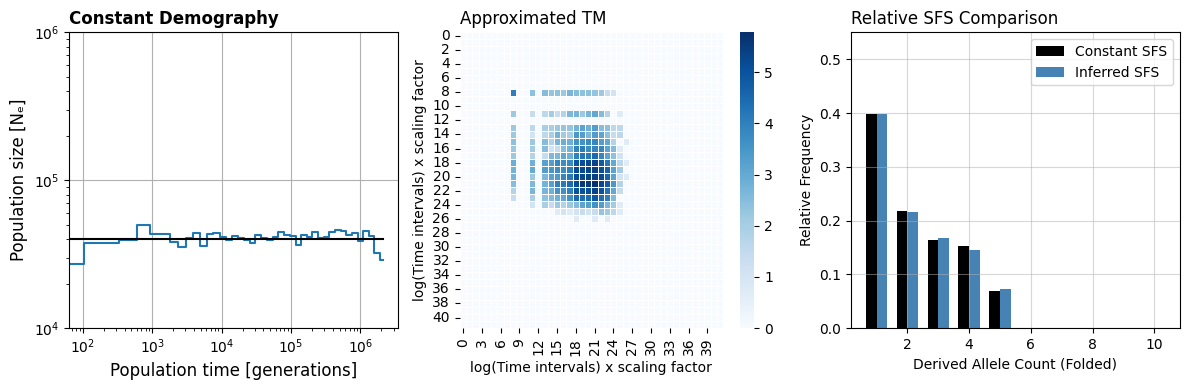

In [ ]:
population_size = sizes
fig, axs = plt.subplots(1, 3, figsize=(12, 4))#, plt.gca()
ax = axs[0]
sns.lineplot(x=population_time, y=population_size, drawstyle="steps-mid", ax=ax)
sns.lineplot(x=population_time, y=y_true, drawstyle="steps-mid", color='black', ax=ax)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Population time [generations]", fontsize=12)
ax.set_title("Constant Demography", fontsize=12, fontweight='bold', loc='left')

ax.grid()

# 1) Plot transition matrix as before
ax = axs[1]
plot_transition_matrix(ax, tm_np)
ax.set_title("Approximated TM", loc='left')


# 2) Compute & plot relative SFS
ax = axs[2]
allele_counts = np.arange(1, sim_sfs.shape[1] + 1)
width = 0.35

# normalize per replicate, then average
const_rel = (sim_sfs / sim_sfs.sum(axis=1, keepdims=True)).mean(axis=0)
inf_rel   = (inf_sfs  / inf_sfs.sum(axis=1, keepdims=True)).mean(axis=0)

ax.bar(allele_counts - width/2, const_rel, width=width, label="Constant SFS", color='black')
ax.bar(allele_counts + width/2, inf_rel,   width=width, label="Inferred SFS",  color='steelblue')

ax.set_xlabel("Derived Allele Count (Folded)")
ax.set_ylabel("Relative Frequency")
ax.set_title("Relative SFS Comparison", loc='left')
ax.set(ylim=(0, 0.55))


ax.legend()
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('./figures/constant_demography_v2_relative.png', dpi=300)
plt.show()


In [21]:
# expansion
model_idx = 36
y_preds = []
for seed in seeds:
    model, model_idx = load_model_checkpoint(model, model_idx)
    demography_object = create_demography_object(expansion_sizes, expansion_times)
    tm_np, tm_tensor, pop_size_tensor = simulate_data(
        seed, demography_object, population_time, window_size, empirical_scaling_factor
    )
    print("TM tensor sum:", tm_tensor.sum())
    predictions, targets, loss = run_inference(model, tm_tensor, pop_size_tensor, criterion, device)
    print("Loss:", loss)
    y_true = targets.detach().cpu().numpy()[0]
    y_pred = predictions.detach().cpu().numpy()[0]
    y_preds.append(y_pred)
    print(f"TM sum: {tm_tensor.sum()}")


#np.savez("./cache/expansion_y_preds.npz", y_preds)
#np.savez("./cache/expansion_tm.npz", tm_np)
#np.savez("./cache/expansion_y_true.npz", y_true)

TM tensor sum: tensor(401.8325)
Loss: tensor(0.2010, device='cuda:0')
TM sum: 401.83251953125
TM tensor sum: tensor(416.6609)
Loss: tensor(0.1657, device='cuda:0')
TM sum: 416.6609191894531
TM tensor sum: tensor(437.6962)
Loss: tensor(0.1232, device='cuda:0')
TM sum: 437.6961669921875
TM tensor sum: tensor(396.0501)
Loss: tensor(0.1713, device='cuda:0')
TM sum: 396.0500793457031
TM tensor sum: tensor(421.4759)
Loss: tensor(0.2185, device='cuda:0')
TM sum: 421.47589111328125


In [22]:
y_preds = np.load("./cache/expansion_y_preds.npz")['arr_0']
y_true = np.exp(np.load("./cache/expansion_y_true.npz")['arr_0'])
tm_np = np.load("./cache/expansion_tm.npz")['arr_0']
demography_object = create_demography_object(expansion_sizes, expansion_times)


avg_pred = np.array(y_preds).mean(0)
sizes = np.exp(avg_pred)
times = population_time
sim_tss = []
for seed in seeds:
    params = {
        'discrete_genome': True,
        'samples': 10, 
        'ploidy': 1,
        'demography': demography_object,
        'recombination_rate': 3.4e-8,
        'random_seed': seed,
        'sequence_length': 4_000_000
    }
    sim_ts = msprime.sim_ancestry(**params)
    sim_ts = msprime.mutate(sim_ts, rate=7e-9, random_seed=seed)
    sim_tss.append(sim_ts)

# simulating under the inferred demography with replicates
inf_tss = []
for seed in seeds:
    demography_object = create_demography_object(sizes, times)
    params['demography'] = demography_object    
    params['random_seed'] = seed
    inf_ts = msprime.sim_ancestry(**params)
    inf_ts = msprime.mutate(inf_ts, rate=7e-9, random_seed=seed)
    inf_tss.append(inf_ts)

sim_sfs = []
inf_sfs = []
for i, seed in enumerate(seeds):
    sim_ts = sim_tss[i]
    inf_ts = inf_tss[i]
    sim_sfs.append(sim_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
    inf_sfs.append(inf_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
sim_sfs = np.array(sim_sfs)
inf_sfs = np.array(inf_sfs)

In [ ]:
#np.savez("./cache/expansion_sfs.npz", sim_sfs, inf_sfs)

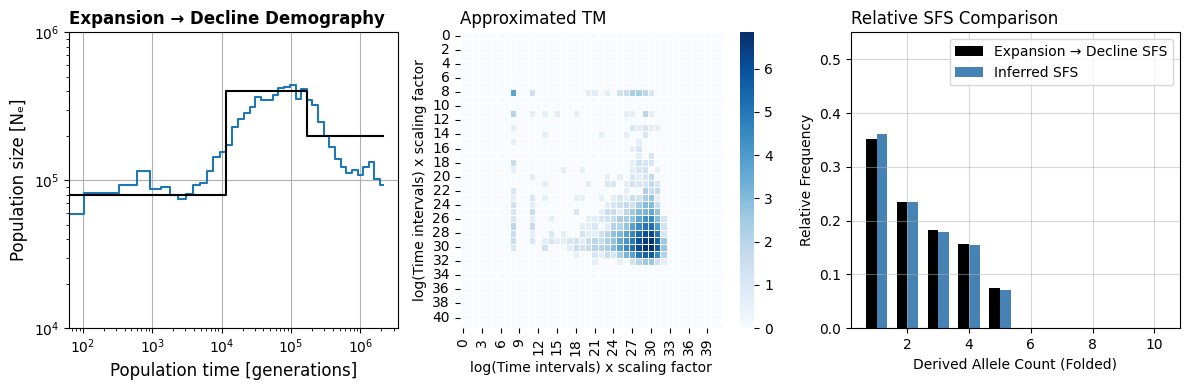

In [23]:
population_size = sizes
fig, axs = plt.subplots(1, 3, figsize=(12, 4))#, plt.gca()
ax = axs[0]
sns.lineplot(x=population_time, y=population_size, drawstyle="steps-mid", ax=ax)
sns.lineplot(x=population_time, y=y_true, drawstyle="steps-mid", color='black', ax=ax)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Population time [generations]", fontsize=12)
ax.set_title("Expansion → Decline Demography", fontsize=12, fontweight='bold', loc='left')
ax.grid()

ax = axs[1]
plot_transition_matrix(ax, tm_np)
ax.set_title("Approximated TM", loc='left')


ax = axs[2]
allele_counts = np.arange(1, sim_sfs.shape[1] + 1)
width = 0.35

# normalize each replicate, then average
exp_rel = (sim_sfs / sim_sfs.sum(axis=1, keepdims=True)).mean(axis=0)
inf_rel = (inf_sfs  / inf_sfs.sum(axis=1, keepdims=True)).mean(axis=0)

# plot
ax.bar(allele_counts - width/2, exp_rel, width=width, label="Expansion → Decline SFS", color='black')
ax.bar(allele_counts + width/2, inf_rel, width=width, label="Inferred SFS", color='steelblue')

ax.set_xlabel("Derived Allele Count (Folded)")
ax.set_ylabel("Relative Frequency")
ax.set_title("Relative SFS Comparison", loc='left')
ax.set(ylim=(0, 0.55))


ax.legend()
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('./figures/expansion_demography_v2_relative.png', dpi=300)
plt.show()


In [24]:
# contraction

model_idx = 36
y_preds = []
for seed in seeds:
    model, model_idx = load_model_checkpoint(model, model_idx)
    demography_object = create_demography_object(contraction_sizes, contraction_times)
    tm_np, tm_tensor, pop_size_tensor = simulate_data(
        seed, demography_object, population_time, window_size, empirical_scaling_factor
    )
    print("TM tensor sum:", tm_tensor.sum())
    predictions, targets, loss = run_inference(model, tm_tensor, pop_size_tensor, criterion, device)
    print("Loss:", loss)
    y_true = targets.detach().cpu().numpy()[0]
    y_pred = predictions.detach().cpu().numpy()[0]
    y_preds.append(y_pred)
    print(f"TM sum: {tm_tensor.sum()}")


#np.savez("./cache/contraction_y_preds.npz", y_preds)
#np.savez("./cache/contraction_tm.npz", tm_np)
#np.savez("./cache/contraction_y_true.npz", y_true)

TM tensor sum: tensor(363.2932)
Loss: tensor(0.1710, device='cuda:0')
TM sum: 363.293212890625
TM tensor sum: tensor(357.4697)
Loss: tensor(0.3013, device='cuda:0')
TM sum: 357.4697265625
TM tensor sum: tensor(363.9881)
Loss: tensor(0.2049, device='cuda:0')
TM sum: 363.9880676269531
TM tensor sum: tensor(377.7550)
Loss: tensor(0.0991, device='cuda:0')
TM sum: 377.7550354003906
TM tensor sum: tensor(368.3956)
Loss: tensor(0.2151, device='cuda:0')
TM sum: 368.39556884765625


In [25]:
y_preds = np.load("./cache/contraction_y_preds.npz")['arr_0']
y_true = np.exp(np.load("./cache/contraction_y_true.npz")['arr_0'])
tm_np = np.load("./cache/contraction_tm.npz")['arr_0']
demography_object = create_demography_object(contraction_sizes, contraction_times)

avg_pred = np.array(y_preds).mean(0)
sizes = np.exp(avg_pred)
times = population_time
sim_tss = []
for seed in seeds:
    params = {
        'discrete_genome': True,
        'samples': 10, 
        'ploidy': 1,
        'demography': demography_object,
        'recombination_rate': 3.4e-8,
        'random_seed': seed,
        'sequence_length': 4_000_000
    }
    sim_ts = msprime.sim_ancestry(**params)
    sim_ts = msprime.mutate(sim_ts, rate=7e-9, random_seed=seed)
    sim_tss.append(sim_ts)

# simmulating under the inferred demography with replicates
inf_tss = []
for seed in seeds:
    demography_object = create_demography_object(sizes, times)
    params['demography'] = demography_object    
    params['random_seed'] = seed
    inf_ts = msprime.sim_ancestry(**params)
    inf_ts = msprime.mutate(inf_ts, rate=7e-9, random_seed=seed)
    inf_tss.append(inf_ts)

sim_sfs = []
inf_sfs = []
for i, seed in enumerate(seeds):
    sim_ts = sim_tss[i]
    inf_ts = inf_tss[i]
    sim_sfs.append(sim_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
    inf_sfs.append(inf_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
sim_sfs = np.array(sim_sfs)
inf_sfs = np.array(inf_sfs)

In [ ]:
#np.savez("./cache/contraction_sfs.npz", sim_sfs, inf_sfs)

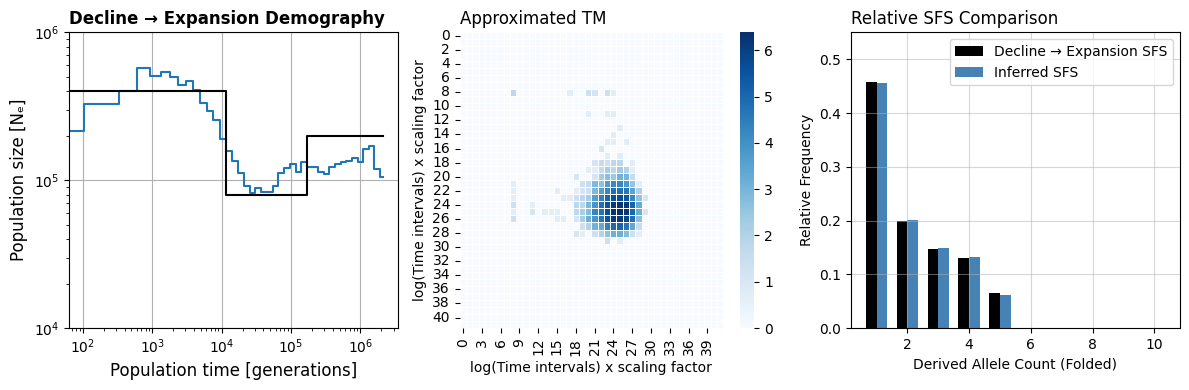

In [ ]:
population_size = sizes
fig, axs = plt.subplots(1, 3, figsize=(12, 4))#, plt.gca()
ax = axs[0]
sns.lineplot(x=population_time, y=population_size, drawstyle="steps-mid", ax=ax)
sns.lineplot(x=population_time, y=y_true, drawstyle="steps-mid", color='black', ax=ax)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Population time [generations]", fontsize=12)
ax.set_title("Decline → Expansion Demography", fontsize=12, fontweight='bold', loc='left')

ax.grid()

ax = axs[1]
plot_transition_matrix(ax, tm_np)
ax.set_title("Approximated TM", loc='left')

ax = axs[2]
allele_counts = np.arange(1, sim_sfs.shape[1] + 1)
width = 0.35

# normalize each replicate so rows sum to 1, then average
contract_rel = (sim_sfs / sim_sfs.sum(axis=1, keepdims=True)).mean(axis=0)
inf_rel      = (inf_sfs  / inf_sfs.sum(axis=1, keepdims=True)).mean(axis=0)

# plot relative SFS
ax.bar(allele_counts - width/2, contract_rel, width=width, label="Decline → Expansion SFS", color='black')
ax.bar(allele_counts + width/2, inf_rel,      width=width, label="Inferred SFS",    color='steelblue')

ax.set_xlabel("Derived Allele Count (Folded)")
ax.set_ylabel("Relative Frequency")
ax.set_title("Relative SFS Comparison", loc='left')
ax.set(ylim=(0, 0.55))

ax.legend()
ax.grid(alpha=0.5)
plt.tight_layout()
#plt.savefig('./figures/contraction_demography_v2_relative.png', dpi=300)
plt.show()

In [27]:
# one step
one_step_sizes = np.array([2*10**5 * 2] * 18 +  [2*10**4 * 4] * 24)
one_step_times = population_time
one_step_demography_object = create_demography_object(one_step_sizes, one_step_times)
y_true = one_step_sizes


(10000, 1000000)

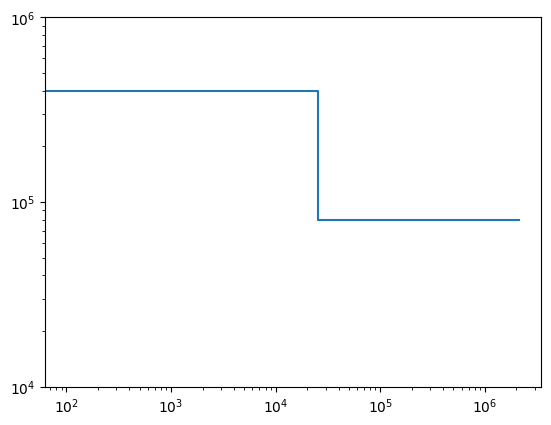

In [ ]:
sns.lineplot(x=population_time, y=one_step_sizes, drawstyle="steps-mid")
plt.yscale("log")
plt.xscale("log")
plt.ylim(10000, 1_000_000)

In [28]:
# one step
model_idx = 36
y_preds = []
for seed in seeds:
    model, model_idx = load_model_checkpoint(model, model_idx)
    demography_object = create_demography_object(one_step_sizes, one_step_times)
    tm_np, tm_tensor, pop_size_tensor = simulate_data(
        seed, demography_object, population_time, window_size, empirical_scaling_factor)
    print("TM tensor sum:", tm_tensor.sum())
    predictions, targets, loss = run_inference(model, tm_tensor, pop_size_tensor, criterion, device)
    print("Loss:", loss)
    y_true = targets.detach().cpu().numpy()[0]
    y_pred = predictions.detach().cpu().numpy()[0]
    y_preds.append(y_pred)
    print(f"TM sum: {tm_tensor.sum()}")

#np.savez("./cache/one_step_y_preds.npz", y_preds)
#np.savez("./cache/one_step_tm.npz", tm_np)
#np.savez("./cache/one_stepy_true.npz", y_true)

TM tensor sum: tensor(296.7181)
Loss: tensor(0.2910, device='cuda:0')
TM sum: 296.71807861328125
TM tensor sum: tensor(295.8866)
Loss: tensor(0.2501, device='cuda:0')
TM sum: 295.8866271972656
TM tensor sum: tensor(318.2549)
Loss: tensor(0.1987, device='cuda:0')
TM sum: 318.2548828125
TM tensor sum: tensor(308.9155)
Loss: tensor(0.2118, device='cuda:0')
TM sum: 308.91546630859375
TM tensor sum: tensor(306.3243)
Loss: tensor(0.1490, device='cuda:0')
TM sum: 306.3243103027344


In [ ]:
y_preds = np.load("./cache/one_step_y_preds.npz")['arr_0']
tm_np = np.load("./cache/one_step_tm.npz")['arr_0']
demography_object = create_demography_object(one_step_sizes, one_step_times)
avg_pred = np.array(y_preds).mean(0)
sizes = np.exp(avg_pred)
times = population_time
sim_tss = []
for seed in seeds:
    params = {
        'discrete_genome': True,
        'samples': 10, 
        'ploidy': 1,
        'demography': demography_object,
        'recombination_rate': 3.4e-8,
        'random_seed': seed,
        'sequence_length': 4_000_000
    }
    sim_ts = msprime.sim_ancestry(**params)
    sim_ts = msprime.mutate(sim_ts, rate=7e-9, random_seed=seed)
    sim_tss.append(sim_ts)

# simmulating under the inferred demography with replicates
inf_tss = []
for seed in seeds:
    demography_object = create_demography_object(sizes, times)
    params['demography'] = demography_object    
    params['random_seed'] = seed
    inf_ts = msprime.sim_ancestry(**params)
    inf_ts = msprime.mutate(inf_ts, rate=7e-9, random_seed=seed)
    inf_tss.append(inf_ts)

sim_sfs = []
inf_sfs = []
for i, seed in enumerate(seeds):
    sim_ts = sim_tss[i]
    inf_ts = inf_tss[i]
    sim_sfs.append(sim_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
    inf_sfs.append(inf_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
sim_sfs = np.array(sim_sfs)
inf_sfs = np.array(inf_sfs)

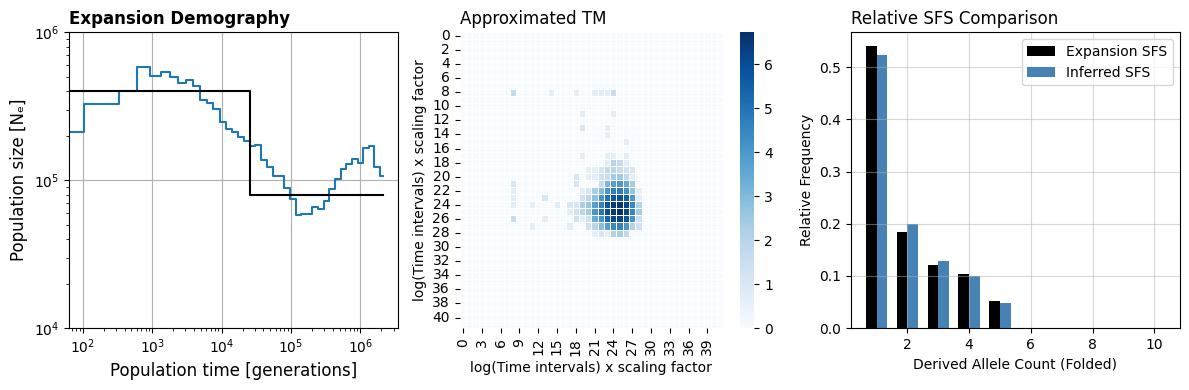

In [ ]:
population_size = sizes
fig, axs = plt.subplots(1, 3, figsize=(12, 4))#, plt.gca()
ax = axs[0]
sns.lineplot(x=population_time, y=population_size, drawstyle="steps-mid", ax=ax)
sns.lineplot(x=population_time, y=y_true, drawstyle="steps-mid", color='black', ax=ax)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Population time [generations]", fontsize=12)
ax.set_title("Expansion Demography", fontsize=12, fontweight='bold', loc='left')

ax.grid()

ax = axs[1]
plot_transition_matrix(ax, tm_np, window_size)
ax.set_title("Approximated TM", loc='left')

ax = axs[2]
allele_counts = np.arange(1, sim_sfs.shape[1] + 1)
width = 0.35

# normalize each replicate so rows sum to 1, then average
expansion_rel = (sim_sfs / sim_sfs.sum(axis=1, keepdims=True)).mean(axis=0)
inf_rel      = (inf_sfs  / inf_sfs.sum(axis=1, keepdims=True)).mean(axis=0)

# plot relative SFS
ax.bar(allele_counts - width/2, expansion_rel, width=width, label="Expansion SFS", color='black')
ax.bar(allele_counts + width/2, inf_rel,      width=width, label="Inferred SFS",    color='steelblue')

ax.set_xlabel("Derived Allele Count (Folded)")
ax.set_ylabel("Relative Frequency")
ax.set_title("Relative SFS Comparison", loc='left')
ax.set(ylim=(0, 0.55))

ax.legend()
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('./figures/onestep_expansion_demography_v2_relative.png', dpi=300)
plt.show()

In [29]:
# one step 2
one_step_sizes2 = np.array([2*10**4 * 4] * 24 + [2*10**5 * 2] * 18 )
one_step_times2 = population_time
one_step_demography_object = create_demography_object(one_step_sizes2, one_step_times2)
y_true = one_step_sizes2

(10000, 1000000)

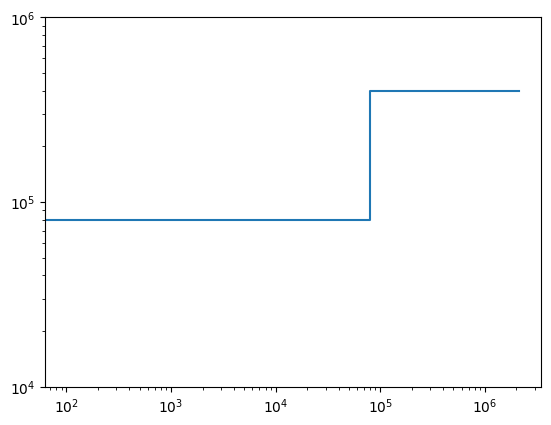

In [80]:
sns.lineplot(x=population_time, y=one_step_sizes2, drawstyle="steps-mid")
plt.yscale("log")
plt.xscale("log")
plt.ylim(10000, 1_000_000)

In [32]:
# one step
model_idx = 36
y_preds = []
for seed in seeds:
    model, model_idx = load_model_checkpoint(model, model_idx)
    demography_object = create_demography_object(one_step_sizes2, one_step_times2)
    tm_np, tm_tensor, pop_size_tensor = simulate_data(
        seed, demography_object, population_time, window_size, empirical_scaling_factor
    )
    print("TM tensor sum:", tm_tensor.sum())
    predictions, targets, loss = run_inference(model, tm_tensor, pop_size_tensor, criterion, device)
    print("Loss:", loss)
    y_true = targets.detach().cpu().numpy()[0]
    y_pred = predictions.detach().cpu().numpy()[0]
    y_preds.append(y_pred)
    print(f"TM sum: {tm_tensor.sum()}")


# plt.savefig("./figurs/Sawtooth-10-Simulations-rhotheta-5-and-tm.png", dpi=300)

#np.savez("./cache/one_step2_y_preds.npz", y_preds)
#np.savez("./cache/one_step2_tm.npz", tm_np)
#np.savez("./cache/one_step2_y_true.npz", y_true)

TM tensor sum: tensor(573.6722)
Loss: tensor(0.2364, device='cuda:0')
TM sum: 573.6721801757812
TM tensor sum: tensor(577.4329)
Loss: tensor(0.1541, device='cuda:0')
TM sum: 577.4329223632812
TM tensor sum: tensor(599.8644)
Loss: tensor(0.2347, device='cuda:0')
TM sum: 599.8644409179688
TM tensor sum: tensor(588.8759)
Loss: tensor(0.1676, device='cuda:0')
TM sum: 588.8758544921875
TM tensor sum: tensor(597.0915)
Loss: tensor(0.1705, device='cuda:0')
TM sum: 597.0914916992188


In [ ]:
y_preds = np.load("./cache/one_step2_y_preds.npz")['arr_0']
tm_np = np.load("./cache/one_step2_tm.npz")['arr_0']

demography_object = create_demography_object(one_step_sizes2, one_step_times2)
avg_pred = np.array(y_preds).mean(0)
sizes = np.exp(avg_pred)
times = population_time
sim_tss = []
for seed in seeds:
    params = {
        'discrete_genome': True,
        'samples': 10, 
        'ploidy': 1,
        'demography': demography_object,
        'recombination_rate': 3.4e-8,
        'random_seed': seed,
        'sequence_length': 4_000_000
    }
    sim_ts = msprime.sim_ancestry(**params)
    sim_ts = msprime.mutate(sim_ts, rate=7e-9, random_seed=seed)
    sim_tss.append(sim_ts)

# simmulating under the inferred demography with replicates
inf_tss = []
for seed in seeds:
    demography_object = create_demography_object(sizes, times)
    params['demography'] = demography_object    
    params['random_seed'] = seed
    inf_ts = msprime.sim_ancestry(**params)
    inf_ts = msprime.mutate(inf_ts, rate=7e-9, random_seed=seed)
    inf_tss.append(inf_ts)

sim_sfs = []
inf_sfs = []
for i, seed in enumerate(seeds):
    sim_ts = sim_tss[i]
    inf_ts = inf_tss[i]
    sim_sfs.append(sim_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
    inf_sfs.append(inf_ts.allele_frequency_spectrum(mode="site", polarised=False, span_normalise=False)[1:])
sim_sfs = np.array(sim_sfs)
inf_sfs = np.array(inf_sfs)

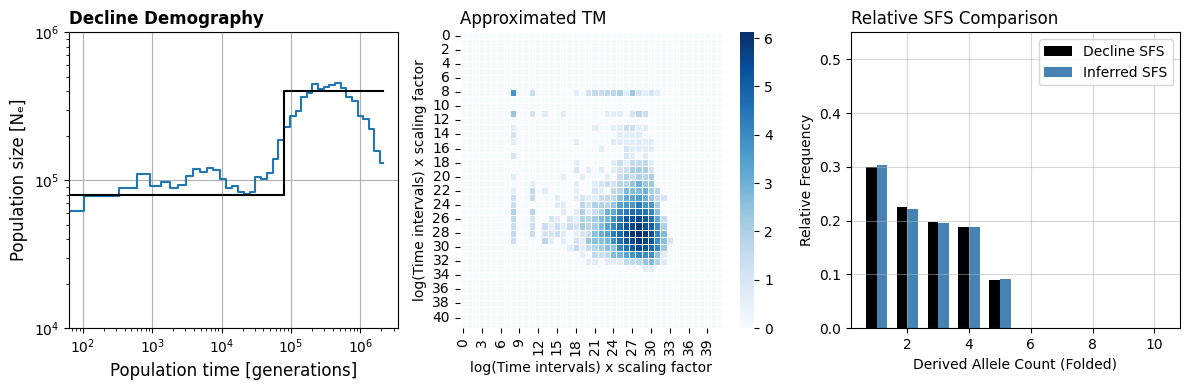

In [90]:
population_size = sizes
fig, axs = plt.subplots(1, 3, figsize=(12, 4))#, plt.gca()
ax = axs[0]
sns.lineplot(x=population_time, y=population_size, drawstyle="steps-mid", ax=ax)
sns.lineplot(x=population_time, y=y_true, drawstyle="steps-mid", color='black', ax=ax)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Population time [generations]", fontsize=12)
ax.set_title("Decline Demography", fontsize=12, fontweight='bold', loc='left')

ax.grid()

ax = axs[1]
plot_transition_matrix(ax, tm_np, window_size)
ax.set_title("Approximated TM", loc='left')

ax = axs[2]
allele_counts = np.arange(1, sim_sfs.shape[1] + 1)
width = 0.35

# normalize each replicate so rows sum to 1, then average
decline_rel = (sim_sfs / sim_sfs.sum(axis=1, keepdims=True)).mean(axis=0)
inf_rel      = (inf_sfs  / inf_sfs.sum(axis=1, keepdims=True)).mean(axis=0)

# plot relative SFS
ax.bar(allele_counts - width/2, decline_rel, width=width, label="Decline SFS", color='black')
ax.bar(allele_counts + width/2, inf_rel,      width=width, label="Inferred SFS",    color='steelblue')

ax.set_xlabel("Derived Allele Count (Folded)")
ax.set_ylabel("Relative Frequency")
ax.set_title("Relative SFS Comparison", loc='left')
ax.set(ylim=(0, 0.55))


ax.legend()
ax.grid(alpha=0.5)
plt.tight_layout()
plt.savefig('./figures/onestep_decline_demography_v2_relative.png', dpi=300)
plt.show()

In [ ]:
# from here on inference for real data

In [34]:
import pandas as pd
from aTMi.misc import binomial_combinations_k2
from inference_lib import encode_minor_alleles_as_derived
from inference_lib import real_data2genotype_matrix_and_positions
from inference_lib import real_genotype_matrix2transition_matrix
from inference_lib import real_genotype_matrix2mutation_sequence

In [35]:
# maf
data_ibnr_5mb_1 = pd.read_csv("./Athaliana_maf/ibnr_multihetsep_snps_1", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_ceu_5mb_1 = pd.read_csv("./Athaliana_maf/ceu_multihetsep_snps_1", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
gm_ibnr_5mb_1, positions_ibnr_5mb_1 = real_data2genotype_matrix_and_positions(data_ibnr_5mb_1)
gm_ceu_5mb_1, positions_ceu_5mb_1 = real_data2genotype_matrix_and_positions(data_ceu_5mb_1)

In [38]:
# bootstrapping various regions
sequence_starts = [0, 2e6, 4e6]
sequence_ends = [2e6, 4e6, 6e6]
np.random.seed(100)
sequence_starts = []
sequence_ends = []
for i in range(20):
    start = int(np.random.uniform(0, 28e6))
    sequence_starts.append(start)
    end = start+np.random.uniform(1e6, 3e6)
    print(f"Region {i+1}: Start = {start}, End = {end:.2f}, Length = {end - start:.2f}")
    sequence_ends.append(int(end))

Region 1: Start = 15215338, End = 16772076.77, Length = 1556738.77
Region 2: Start = 11886492, End = 14576044.26, Length = 2689552.26
Region 3: Start = 132127, End = 1375265.24, Length = 1243138.24
Region 4: Start = 18780974, End = 21432679.51, Length = 2651705.51
Region 5: Start = 3827784, End = 5977970.66, Length = 2150186.66
Region 6: Start = 24957014, End = 26375418.24, Length = 1418404.24
Region 7: Start = 5189190, End = 6405943.78, Length = 1216753.78
Region 8: Start = 6151529, End = 9108776.57, Length = 2957247.57
Region 9: Start = 22727128, End = 24071010.03, Length = 1343882.03
Region 10: Start = 22854292, End = 24402439.49, Length = 1548147.49
Region 11: Start = 12087717, End = 14967776.64, Length = 2880059.64
Region 12: Start = 22894182, End = 24566405.90, Length = 1672223.90
Region 13: Start = 4911492, End = 6657156.09, Length = 1745664.09
Region 14: Start = 159278, End = 1664130.71, Length = 1504852.71
Region 15: Start = 22278550, End = 23309059.94, Length = 1030509.94
Reg

In [39]:
from inference_lib import process_model_predictions

In [40]:
model_idx_range = range(36, 40)
window_size = 20_000

# These lists will store the sum of the transition matrix for each sample.
seq_samples_snp_ibnr = []
seq_samples_snp_ceu = []

# Process IBNR data.
# The genotype pair for IBNR is assumed to be (gm_ibnr_5mb_1, positions_ibnr_5mb_1).
y_preds_ibnr = process_model_predictions(
    model, model_idx_range,
    genotype_pair=(gm_ibnr_5mb_1, positions_ibnr_5mb_1),
    sequence_starts=sequence_starts,
    sequence_ends=sequence_ends,
    window_size=window_size,
    device=device,
    log_list=seq_samples_snp_ibnr
)
y_preds_chromosomes_ibnr_snp = y_preds_ibnr

# Process CEU data.
# The genotype pair for CEU is assumed to be (gm_ceu_5mb_1, positions_ceu_5mb_1).
y_preds_ceu = process_model_predictions(
    model, model_idx_range,
    genotype_pair=(gm_ceu_5mb_1, positions_ceu_5mb_1),
    sequence_starts=sequence_starts,
    sequence_ends=sequence_ends,
    window_size=window_size,
    device=device,
    log_list=seq_samples_snp_ceu
)
y_preds_chromosomes_ceu_snp = y_preds_ceu

# Now you can use y_preds_chromosomes_ibnr_snp and y_preds_chromosomes_ceu_snp as needed.
print("IBNR average predictions:", y_preds_chromosomes_ibnr_snp)
print("CEU average predictions:", y_preds_chromosomes_ceu_snp)


tensor(693.1239)
tensor(1041.8413)
tensor(679.8441)
tensor(1034.2509)
tensor(986.7567)
tensor(732.6495)
tensor(730.2621)
tensor(1131.4880)
tensor(665.6591)
tensor(706.8043)
tensor(997.6666)
tensor(734.9108)
tensor(914.7993)
tensor(763.9559)
tensor(543.4839)
tensor(770.6194)
tensor(902.7167)
tensor(1053.3512)
tensor(630.8060)
tensor(942.9083)
tensor(693.1239)
tensor(1041.8413)
tensor(679.8441)
tensor(1034.2509)
tensor(986.7567)
tensor(732.6495)
tensor(730.2621)
tensor(1131.4880)
tensor(665.6591)
tensor(706.8043)
tensor(997.6666)
tensor(734.9108)
tensor(914.7993)
tensor(763.9559)
tensor(543.4839)
tensor(770.6194)
tensor(902.7167)
tensor(1053.3512)
tensor(630.8060)
tensor(942.9083)
tensor(693.1239)
tensor(1041.8413)
tensor(679.8441)
tensor(1034.2509)
tensor(986.7567)
tensor(732.6495)
tensor(730.2621)
tensor(1131.4880)
tensor(665.6591)
tensor(706.8043)
tensor(997.6666)
tensor(734.9108)
tensor(914.7993)
tensor(763.9559)
tensor(543.4839)
tensor(770.6194)
tensor(902.7167)
tensor(1053.3512)
te

Text(0.5, 0, 'Population time [generations]')

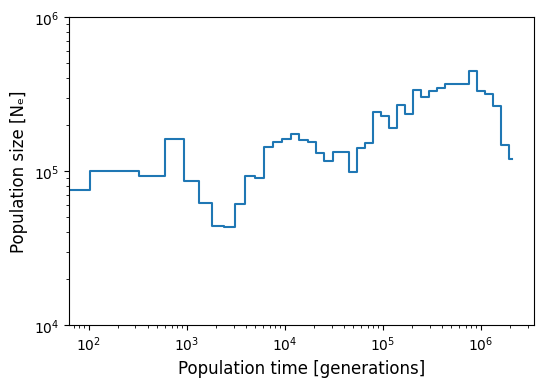

In [ ]:
population_size = np.exp(y_preds_chromosomes_ibnr_snp[0])
#population_size = np.exp(y_preds_chromosomes_ceu_snp[0])

fig, ax = plt.figure(figsize=(6, 4)), plt.gca()
sns.lineplot(x=population_time, y=population_size, drawstyle="steps-mid")
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Population time [generations]", fontsize=12)

In [43]:
data_ibnr_5mb_1 = pd.read_csv("./Athaliana_2/ibnr_multihetsep_smps_5mb_1", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_ibnr_5mb_2 = pd.read_csv("./Athaliana_2/ibnr_multihetsep_smps_5mb_2", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_ibnr_5mb_3 = pd.read_csv("./Athaliana_2/ibnr_multihetsep_smps_5mb_3", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_ibnr_5mb_4 = pd.read_csv("./Athaliana_2/ibnr_multihetsep_smps_5mb_4", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_ibnr_5mb_5 = pd.read_csv("./Athaliana_2/ibnr_multihetsep_smps_5mb_5", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_ceu_5mb_1 = pd.read_csv("./Athaliana_2/ceu_multihetsep_smps_5mb_1", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_ceu_5mb_2 = pd.read_csv("./Athaliana_2/ceu_multihetsep_smps_5mb_2", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_ceu_5mb_3 = pd.read_csv("./Athaliana_2/ceu_multihetsep_smps_5mb_3", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_ceu_5mb_4 = pd.read_csv("./Athaliana_2/ceu_multihetsep_smps_5mb_4", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_ceu_5mb_5 = pd.read_csv("./Athaliana_2/ceu_multihetsep_smps_5mb_5", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])

gm_ibnr_5mb_1, positions_ibnr_5mb_1 = real_data2genotype_matrix_and_positions(data_ibnr_5mb_1)
gm_ibnr_5mb_2, positions_ibnr_5mb_2 = real_data2genotype_matrix_and_positions(data_ibnr_5mb_2)
gm_ibnr_5mb_3, positions_ibnr_5mb_3 = real_data2genotype_matrix_and_positions(data_ibnr_5mb_3)
gm_ibnr_5mb_4, positions_ibnr_5mb_4 = real_data2genotype_matrix_and_positions(data_ibnr_5mb_4)
gm_ibnr_5mb_5, positions_ibnr_5mb_5 = real_data2genotype_matrix_and_positions(data_ibnr_5mb_5)
gm_ceu_5mb_1, positions_ceu_5mb_1 = real_data2genotype_matrix_and_positions(data_ceu_5mb_1)
gm_ceu_5mb_2, positions_ceu_5mb_2 = real_data2genotype_matrix_and_positions(data_ceu_5mb_2)
gm_ceu_5mb_3, positions_ceu_5mb_3 = real_data2genotype_matrix_and_positions(data_ceu_5mb_3)
gm_ceu_5mb_4, positions_ceu_5mb_4 = real_data2genotype_matrix_and_positions(data_ceu_5mb_4)
gm_ceu_5mb_5, positions_ceu_5mb_5 = real_data2genotype_matrix_and_positions(data_ceu_5mb_5)

In [44]:
from inference_lib import process_genotype_predictions
sequence_starts = [0, 0, 0, 0, 1, 1, 1, 1]
sequence_ends = [1e6, 1.25e6, 1.5e6, 2e6, 2e6, 2.25e6, 2.5e6, 3e6]

In [45]:
# Range of model checkpoint indices.
model_indices = range(36, 40)
window_size = 20_000

# List to collect the transition matrix sums.
seq_samples_ceu = []

# Define the list of genotype pairs for CEU.
genotype_pairs = [
    (gm_ceu_5mb_1, positions_ceu_5mb_1),
    (gm_ceu_5mb_2, positions_ceu_5mb_2),
    (gm_ceu_5mb_3, positions_ceu_5mb_3),
    (gm_ceu_5mb_4, positions_ceu_5mb_4),
    (gm_ceu_5mb_5, positions_ceu_5mb_5)
]

y_preds_chromosomes_models = []
for idx in model_indices:
    checkpoint = f"./models/model-dataset_60k_window20k_L4_scaling3_diff_checkpoint_{idx}.pth"
    model.load_state_dict(torch.load(checkpoint)['model'])
    # Process all genotype pairs for the current model.
    y_preds_chromosomes = process_genotype_predictions(
        model, genotype_pairs, sequence_starts, sequence_ends, window_size, device, seq_samples_ceu
    )
    y_preds_chromosomes_models.append(y_preds_chromosomes)

# Average predictions over models and then over chromosomes.
y_preds_arr = np.array(y_preds_chromosomes_models)
y_preds_chromosomes_models_avg = y_preds_arr.mean(axis=0).mean(axis=1)
y_preds_chromosomes_ceu_smp = y_preds_chromosomes_models_avg

print("Averaged predictions:", y_preds_chromosomes_ceu_smp)
# Optionally, use or save y_preds_chromosomes_ceu_smp as needed.

tensor(394.6583)
tensor(490.1767)
tensor(540.8994)
tensor(659.6013)
tensor(659.5731)
tensor(704.9531)
tensor(762.5483)
tensor(847.8824)
tensor(592.2693)
tensor(648.6266)
tensor(696.2576)
tensor(786.1593)
tensor(786.1593)
tensor(813.8564)
tensor(853.9910)
tensor(889.1562)
tensor(469.7286)
tensor(529.3489)
tensor(588.4260)
tensor(657.3376)
tensor(657.3376)
tensor(693.0135)
tensor(727.1492)
tensor(792.0917)
tensor(451.2543)
tensor(533.6840)
tensor(562.3401)
tensor(669.9946)
tensor(670.4274)
tensor(703.1371)
tensor(768.6957)
tensor(828.5811)
tensor(494.5894)
tensor(552.6572)
tensor(596.3990)
tensor(724.0917)
tensor(724.0917)
tensor(756.8820)
tensor(784.7809)
tensor(848.1483)
tensor(394.6583)
tensor(490.1767)
tensor(540.8994)
tensor(659.6013)
tensor(659.5731)
tensor(704.9531)
tensor(762.5483)
tensor(847.8824)
tensor(592.2693)
tensor(648.6266)
tensor(696.2576)
tensor(786.1593)
tensor(786.1593)
tensor(813.8564)
tensor(853.9910)
tensor(889.1562)
tensor(469.7286)
tensor(529.3489)
tensor(588.426

In [65]:
# Range of model checkpoint indices.
model_indices = range(36, 40)
window_size = 20_000

# List to collect the transition matrix sums.
seq_samples_ibnr = []

# Define the list of genotype pairs for CEU.
genotype_pairs = [
    (gm_ibnr_5mb_1, positions_ibnr_5mb_1),
    (gm_ibnr_5mb_2, positions_ibnr_5mb_2),
    (gm_ibnr_5mb_3, positions_ibnr_5mb_3),
    (gm_ibnr_5mb_4, positions_ibnr_5mb_4),
    (gm_ibnr_5mb_5, positions_ibnr_5mb_5)
]

y_preds_chromosomes_models = []
for idx in model_indices:
    checkpoint = f"./models/model-dataset_60k_window20k_L4_scaling3_diff_checkpoint_{idx}.pth"
    model.load_state_dict(torch.load(checkpoint)['model'])
    # Process all genotype pairs for the current model.
    y_preds_chromosomes = process_genotype_predictions(
        model, genotype_pairs, sequence_starts, sequence_ends, window_size, device, seq_samples_ibnr
    )
    y_preds_chromosomes_models.append(y_preds_chromosomes)

# Average predictions over models and then over chromosomes.
y_preds_arr = np.array(y_preds_chromosomes_models)
y_preds_chromosomes_models_avg = y_preds_arr.mean(axis=0).mean(axis=1)
y_preds_chromosomes_ibnr_smp = y_preds_chromosomes_models_avg

print("Averaged predictions:", y_preds_chromosomes_ibnr_smp)

tensor(444.3698)
tensor(537.8917)
tensor(601.1479)
tensor(729.6609)
tensor(729.6628)
tensor(769.4643)
tensor(810.1158)
tensor(899.7880)
tensor(600.0834)
tensor(655.4244)
tensor(695.3029)
tensor(814.2676)
tensor(814.2676)
tensor(858.6890)
tensor(904.7045)
tensor(959.8665)
tensor(492.8301)
tensor(560.2567)
tensor(624.0921)
tensor(722.6007)
tensor(722.6007)
tensor(750.7982)
tensor(794.6337)
tensor(859.3864)
tensor(508.9783)
tensor(605.0452)
tensor(632.0860)
tensor(741.4394)
tensor(741.4370)
tensor(764.2644)
tensor(825.4406)
tensor(895.2330)
tensor(492.6565)
tensor(548.7963)
tensor(603.2195)
tensor(695.3867)
tensor(695.3867)
tensor(732.8518)
tensor(762.7190)
tensor(840.6005)
tensor(444.3698)
tensor(537.8917)
tensor(601.1479)
tensor(729.6609)
tensor(729.6628)
tensor(769.4643)
tensor(810.1158)
tensor(899.7880)
tensor(600.0834)
tensor(655.4244)
tensor(695.3029)
tensor(814.2676)
tensor(814.2676)
tensor(858.6890)
tensor(904.7045)
tensor(959.8665)
tensor(492.8301)
tensor(560.2567)
tensor(624.092

Text(0.5, 0, 'Population time [generations]')

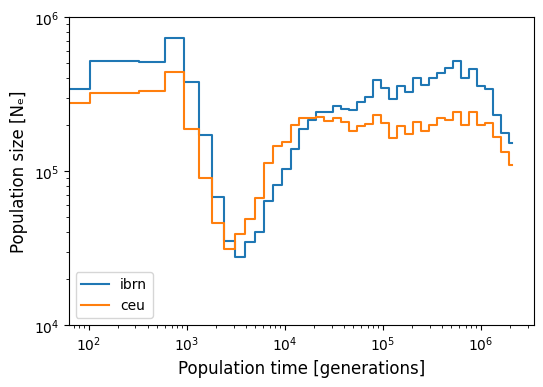

In [47]:
ibnr = np.exp(y_preds_chromosomes_ibnr_smp.mean(0))
ceu = np.exp(y_preds_chromosomes_ceu_smp.mean(0))


fig, ax = plt.figure(figsize=(6, 4)), plt.gca()
sns.lineplot(x=population_time, y=ibnr, drawstyle="steps-mid", label="ibrn")
sns.lineplot(x=population_time, y=ceu, drawstyle="steps-mid", label="ceu")

ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Population time [generations]", fontsize=12)

In [ ]:
# brachypodium

In [48]:
# newest stuff no MAF

data_group12_smp_5mb_1 = pd.read_csv("./Bd/group1.2_multihetsep_smps_5mb_1", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_group12_smp_5mb_2 = pd.read_csv("./Bd/group1.2_multihetsep_smps_5mb_2", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_group12_smp_5mb_3 = pd.read_csv("./Bd/group1.2_multihetsep_smps_5mb_3", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_group12_smp_5mb_4 = pd.read_csv("./Bd/group1.2_multihetsep_smps_5mb_4", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])
data_group12_smp_5mb_5 = pd.read_csv("./Bd/group1.2_multihetsep_smps_5mb_5", sep="\t", names=['chr', 'pos', 'space_prev_pos', 'alleles'])

In [49]:
gm_group_smp_5mb_1, positions_group_smp_5mb_1 = real_data2genotype_matrix_and_positions(data_group12_smp_5mb_1)
gm_group_smp_5mb_2, positions_group_smp_5mb_2 = real_data2genotype_matrix_and_positions(data_group12_smp_5mb_2)
gm_group_smp_5mb_3, positions_group_smp_5mb_3 = real_data2genotype_matrix_and_positions(data_group12_smp_5mb_3)
gm_group_smp_5mb_4, positions_group_smp_5mb_4 = real_data2genotype_matrix_and_positions(data_group12_smp_5mb_4)
gm_group_smp_5mb_5, positions_group_smp_5mb_5 = real_data2genotype_matrix_and_positions(data_group12_smp_5mb_5)

In [50]:
# Range of model checkpoint indices.
model_indices = range(36, 40)
window_size = 20_000

# List to collect the transition matrix sums.
seq_samples_group = []

# Define the list of genotype pairs for CEU.
genotype_pairs = [
    (gm_group_smp_5mb_1, positions_group_smp_5mb_1),
    (gm_group_smp_5mb_2, positions_group_smp_5mb_2),
    (gm_group_smp_5mb_3, positions_group_smp_5mb_3),
    (gm_group_smp_5mb_4, positions_group_smp_5mb_4),
    (gm_group_smp_5mb_5, positions_group_smp_5mb_5)
]

y_preds_chromosomes_models = []
for idx in model_indices:
    checkpoint = f"./models/model-dataset_60k_window20k_L4_scaling3_diff_checkpoint_{idx}.pth"
    model.load_state_dict(torch.load(checkpoint)['model'])
    # Process all genotype pairs for the current model.
    y_preds_chromosomes = process_genotype_predictions(
        model, genotype_pairs, sequence_starts, sequence_ends, window_size, device, seq_samples_group
    )
    y_preds_chromosomes_models.append(y_preds_chromosomes)

# Average predictions over models and then over chromosomes.
y_preds_arr = np.array(y_preds_chromosomes_models)
y_preds_chromosomes_models_avg = y_preds_arr.mean(axis=0).mean(axis=1)
y_preds_chromosomes_group_smp = y_preds_chromosomes_models_avg

print("Averaged predictions:", y_preds_chromosomes_group_smp)
# Optionally, use or save y_preds_chromosomes_ceu_smp as needed.

tensor(458.5876)
tensor(536.9068)


tensor(563.2070)
tensor(602.8505)
tensor(602.8474)
tensor(630.0592)
tensor(699.2808)
tensor(737.8093)
tensor(347.0241)
tensor(366.4675)
tensor(473.7834)
tensor(532.6423)
tensor(533.1213)
tensor(554.7928)
tensor(569.1782)
tensor(606.4316)
tensor(382.8550)
tensor(434.7900)
tensor(458.6887)
tensor(498.2617)
tensor(498.2617)
tensor(517.6960)
tensor(539.3508)
tensor(585.0009)
tensor(559.3669)
tensor(623.7668)
tensor(656.9367)
tensor(755.1495)
tensor(755.1495)
tensor(791.4455)
tensor(819.8780)
tensor(876.3663)
tensor(363.0172)
tensor(441.5895)
tensor(551.0854)
tensor(628.6540)
tensor(628.7136)
tensor(686.8204)
tensor(723.3533)
tensor(814.1486)
tensor(458.5876)
tensor(536.9068)
tensor(563.2070)
tensor(602.8505)
tensor(602.8474)
tensor(630.0592)
tensor(699.2808)
tensor(737.8093)
tensor(347.0241)
tensor(366.4675)
tensor(473.7834)
tensor(532.6423)
tensor(533.1213)
tensor(554.7928)
tensor(569.1782)
tensor(606.4316)
tensor(382.8550)
tensor(434.7900)
tensor(458.6887)
tensor(498.2617)
tensor(498.261

Text(0.5, 0, 'Population time [generations]')

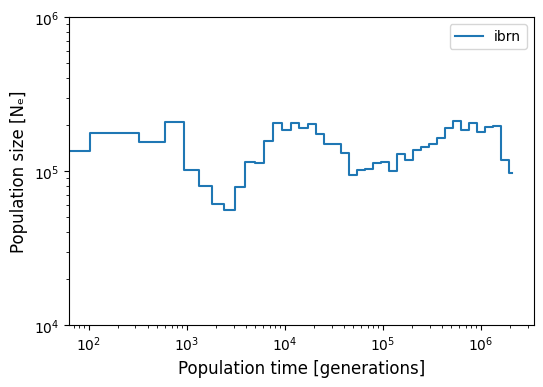

In [51]:
group = np.exp(y_preds_chromosomes_group_smp.mean(0))

fig, ax = plt.figure(figsize=(6, 4)), plt.gca()
sns.lineplot(x=population_time, y=group, drawstyle="steps-mid", label="ibrn")

ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Population time [generations]", fontsize=12)

In [58]:
y_preds_saw = np.load("./cache/sawtooth_y_preds.npz")['arr_0']
y_true_saw = np.exp(np.load("./cache/sawtooth_y_true.npz")['arr_0'])

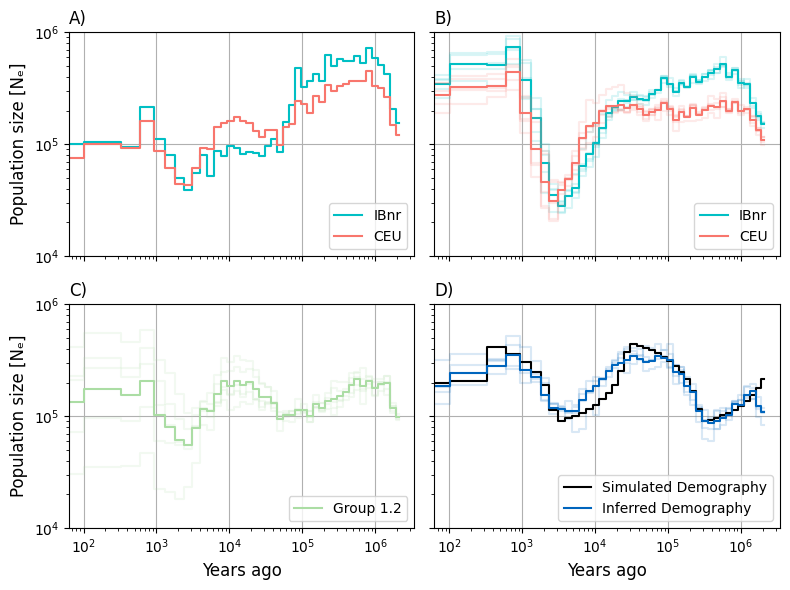

In [67]:

fig, axs = plt.subplots(2, 2, figsize=(8, 6), sharex=True, sharey=True)


ax = axs[0][0]
for i in range(1):
    sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_ibnr_snp[i]), drawstyle="steps-mid", ax=ax, c="#00BFC4", alpha=0.15)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Years ago", fontsize=12)
#ax.set_title(f"$Arabidopsis$ $thaliana$ Demography:\nSNP (chromosomes 1)", loc="left", fontsize=12)
ax.set_title(f"A)", loc="left", fontsize=12)

ax.grid()
sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_ibnr_snp.mean(0)), drawstyle="steps-mid", ax=ax, c="#00BFC4",  label="IBnr")
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))

for i in range(1):
    sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_ceu_snp[i]), drawstyle="steps-mid", ax=ax, c="#F8766D", alpha=0.15)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Years ago", fontsize=12)
#ax.set_title(f"A) $Arabidopsis$ $thaliana$ Demography:\nSNP (chromosomes 1)", loc="left", fontsize=12)
ax.set_title(f"A)", loc="left", fontsize=12)

ax.grid()
sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_ceu_snp.mean(0)), drawstyle="steps-mid", ax=ax, c="#F8766D",  label="CEU")
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.legend(loc="lower right")

ax.grid()
plt.tight_layout()





ax = axs[0][1]
for i in range(5):
    sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_ibnr_smp[i]), drawstyle="steps-mid", ax=ax, c="#00BFC4", alpha=0.15)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Years ago", fontsize=12)
#ax.set_title(f"$Arabidopsis$ $thaliana$ Demography:\nSMP (chromosomes 1-5)", loc="left", fontsize=12)
ax.set_title(f"B)", loc="left", fontsize=12)

ax.grid()
sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_ibnr_smp.mean(0)), drawstyle="steps-mid", ax=ax, c="#00BFC4",  label="IBnr")
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))

for i in range(5):
    sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_ceu_smp[i]), drawstyle="steps-mid", ax=ax, c="#F8766D", alpha=0.15)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Years ago", fontsize=12)
#ax.set_title(f"B) $Arabidopsis$ $thaliana$ Demography:\nSMP (chromosomes 1-5)", loc="left", fontsize=12)
ax.set_title(f"B)", loc="left", fontsize=12)

ax.grid(True)
sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_ceu_smp.mean(0)), drawstyle="steps-mid", ax=ax, c="#F8766D",  label="CEU")
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.legend(loc="lower right")



ax = axs[1][0]
#for i in range(5):
#    sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_group11_smp[i]), drawstyle="steps-mid", ax=ax, c="#FDAE61", alpha=0.15)
#ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
#ax.set_ylabel("Population size [Nₑ]", fontsize=12)
#ax.set_xlabel("Years ago", fontsize=12)
##ax.set_title(f"$Brachypodium$ Demography:\nSMP (chromosomes 1-5)", loc="left", fontsize=12)
#ax.set_title(f"C)", loc="left", fontsize=12)

#ax.grid()
#sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_group11_smp.mean(0)), drawstyle="steps-mid", ax=ax, c="#FDAE61",  label="Group 1.1")
#ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))

for i in range(5):
    sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_group_smp[i]), drawstyle="steps-mid", ax=ax, c="#ABDDA4", alpha=0.15)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Years ago", fontsize=12)
#ax.set_title(f"C) $Brachypodium$ Demography:\nSMP (chromosomes 1-5)", loc="left", fontsize=12)
ax.set_title(f"C)", loc="left", fontsize=12)

ax.grid()
sns.lineplot(x=population_time, y=np.exp(y_preds_chromosomes_group_smp.mean(0)), drawstyle="steps-mid", ax=ax, c="#ABDDA4",  label="Group 1.2")
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.grid(True)
ax.legend(loc="lower right")


ax = axs[1][1]
for i in range(4):
    sns.lineplot(x=population_time, y=np.exp(y_preds_saw[i]), drawstyle="steps-mid", ax=ax, c="#0065bd", alpha=0.15)
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.set_ylabel("Population size [Nₑ]", fontsize=12)
ax.set_xlabel("Years ago", fontsize=12)
ax.set_title(f"D)", loc="left", fontsize=12)
ax.grid()
sns.lineplot(x=population_time, y=np.array(y_true_saw), drawstyle="steps-mid", ax=ax, c="black",  label="Simulated Demography")
sns.lineplot(x=population_time, y=np.exp(np.array(y_preds_saw).mean(0)), drawstyle="steps-mid", ax=ax, c="#0065bd",  label="Inferred Demography")
ax.set(yscale="log", xscale="log", ylim=(10000, 1_000_000))
ax.legend(loc="lower right")



ax.grid(True)
plt.tight_layout()

plt.savefig("Demographies_4panel_diff_L4_no11.pdf", dpi = 400)

In [ ]:
(442413, 2980)
(22026, 1096)
(4914, 1096)

In [66]:
hlines = [
    [13, 8], 
    [10, 7],  
    [9, 7]    # for the third figure
]
print(np.exp(13),np.exp(8))
print(np.exp(10),np.exp(7))
print(np.exp(9),np.exp(7))

442413.3920089205 2980.9579870417283
22026.465794806718 1096.6331584284585
8103.083927575384 1096.6331584284585


In [ ]:
(442413.3920089205, 2980.9579870417283)
(22026.465794806718, 1096.6331584284585)
(8103.083927575384, 1096.6331584284585)

In [ ]:
np.save("seq_samples_snp_ibnr.npy", seq_samples_snp_ibnr)
np.save("seq_samples_snp_ceu.npy", seq_samples_snp_ceu)
np.save("seq_samples_ibnr.npy", seq_samples_ibnr)
np.save("seq_samples_ceu.npy", seq_samples_ceu)
np.save("seq_samples_12.npy", seq_samples_group)

In [ ]:
seq_samples_snp_ibnr = np.load("seq_samples_snp_ibnr.npy")
seq_samples_snp_ceu = np.load("seq_samples_snp_ceu.npy")
seq_samples_ibnr = np.load("seq_samples_ibnr.npy")
seq_samples_ceu = np.load("seq_samples_ceu.npy")
seq_samples_12 = np.load("seq_samples_group.npy")